In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('./data/train.csv')

In [5]:
data.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0
5,5,Female,31,1,47.0,1,< 1 Year,No,28150.0,152.0,197,0
6,6,Male,23,1,45.0,1,< 1 Year,No,27128.0,152.0,190,0
7,7,Female,47,1,8.0,0,1-2 Year,Yes,40659.0,26.0,262,1
8,8,Female,26,1,28.0,1,< 1 Year,No,31639.0,152.0,36,0
9,9,Female,66,1,11.0,0,1-2 Year,Yes,2630.0,26.0,125,0


In [6]:
len(data)

11504798

In [3]:
data_train_full = data.head(5000000)

In [8]:
len(data_train)

5000000

Разобьем на тест и валидацию (бустинги учатся довольно долго, поэтому кросс - валидацию делать не будем):

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
data_train, data_val = train_test_split(data_train_full, test_size=0.2, stratify=data_train_full['Response'])

In [6]:
import sys
import os

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

Сделаем колхозно - колотырно, и не будем импортировать функции, а просто скопипастим код, но это тетрадка с экспериментами, поэтому можно:

In [8]:
def fit_preprocessor(train_df):
    """
    Рассчитывает все параметры препроцессинга на обучающих данных
    """
    preprocessor_params = {}

    #print("Обучение препроцессора на train данных...")

    # 1. Медианы для заполнения пропусков в числовых признаках
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns
    medians = {}
    for col in numeric_cols:
        if col not in ['Response']:  # Исключаем целевую переменную
            medians[col] = train_df[col].median()
    preprocessor_params['medians'] = medians
    #print(f"  Рассчитаны медианы для {len(medians)} признаков")

    # 2. LabelEncoders для категориальных признаков
    label_encoders = {}

    # Для бинарных категориальных признаков
    binary_cols = ['Gender', 'Vehicle_Damage']
    for col in binary_cols:
        if col in train_df.columns:
            le = LabelEncoder()
            # Преобразуем в строку и обучаем
            train_df[col] = train_df[col].astype(str)
            le.fit(train_df[col])
            label_encoders[col] = le
            #print(f"  Обучен LabelEncoder для {col}")

    # Для Vehicle_Age - создаем маппинг
    if 'Vehicle_Age' in train_df.columns:
        vehicle_age_mapping = {
            '< 1 Year': 0,
            '1-2 Year': 1,
            '> 2 Years': 2
        }
        preprocessor_params['vehicle_age_mapping'] = vehicle_age_mapping
        #print("  Создан маппинг для Vehicle_Age")

    preprocessor_params['label_encoders'] = label_encoders

    # 3. Квантили для удаления выбросов
    if 'Annual_Premium' in train_df.columns:
        premium_q99 = train_df['Annual_Premium'].quantile(0.999)
        preprocessor_params['premium_q99'] = premium_q99
        #print(f"  Рассчитан 99.9% квантиль для Annual_Premium: {premium_q99}")

    # 4. Границы для Age групп
    if 'Age' in train_df.columns:
        age_bins = [18, 25, 35, 50, 65, 100]
        preprocessor_params['age_bins'] = age_bins
        #print(f"  Определены границы Age групп: {age_bins}")

    # 5. Квантили для Premium_Group
    if 'Annual_Premium' in train_df.columns:
        try:
            # Определяем квантили на train
            premium_quantiles = np.percentile(train_df['Annual_Premium'], [0, 20, 40, 60, 80, 100])
            preprocessor_params['premium_quantiles'] = premium_quantiles.tolist()
            #print(f"  Рассчитаны квантили для Premium_Group: {premium_quantiles}")
        except Exception as e:
            print(f"  Не удалось рассчитать квантили для Premium_Group: {e}")

    # 6. StandardScaler для числовых признаков
    numeric_features = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code', 'Policy_Sales_Channel']
    numeric_features = [col for col in numeric_features if col in train_df.columns]

    if numeric_features:
        scaler = StandardScaler()
        # Преобразуем в float перед обучением
        train_numeric = train_df[numeric_features].astype('float64')
        scaler.fit(train_numeric)
        preprocessor_params['scaler'] = scaler
        preprocessor_params['numeric_features'] = numeric_features
        #print(f"  Обучен StandardScaler для признаков: {numeric_features}")

    return preprocessor_params


# Функция для применения препроцессора (к train и test)
def apply_preprocessor(df, preprocessor_params, is_train=False):
    """
    Применяет параметры препроцессора к данным
    is_train: True если это обучающие данные (для них удаляем выбросы)
    """
    df_processed = df.copy()

    # 1. Заполнение пропусков медианами (из train)
    if 'medians' in preprocessor_params:
        for col, median_val in preprocessor_params['medians'].items():
            if col in df_processed.columns:
                if df_processed[col].isnull().sum() > 0:
                    df_processed.loc[df_processed[col].isnull(), col] = median_val
                    #if is_train:
                        #print(f"  Заполнено пропусков в {col}: {df_processed[col].isnull().sum()}")

    # 2. Кодирование категориальных признаков
    if 'label_encoders' in preprocessor_params:
        for col, le in preprocessor_params['label_encoders'].items():
            if col in df_processed.columns:
                # Преобразуем в строку и применяем кодировку
                df_processed[col] = df_processed[col].astype(str)
                # Используем transform, а не fit_transform!
                try:
                    df_processed[col] = le.transform(df_processed[col])
                except ValueError as e:
                    # Если встретились новые значения в тесте, кодируем как -1
                    #print(f"  Предупреждение: новые значения в {col}, кодируем как -1")
                    # Создаем маппинг известных значений
                    known_values = set(le.classes_)

                    # Функция для преобразования
                    def encode_value(x):
                        return le.transform([x])[0] if x in known_values else -1

                    df_processed[col] = df_processed[col].apply(encode_value)

    # 3. Кодирование Vehicle_Age
    if 'vehicle_age_mapping' in preprocessor_params and 'Vehicle_Age' in df_processed.columns:
        vehicle_age_mapping = preprocessor_params['vehicle_age_mapping']
        df_processed['Vehicle_Age'] = df_processed['Vehicle_Age'].map(vehicle_age_mapping)
        # Заполняем пропуски значением 1 (самое частое)
        if df_processed['Vehicle_Age'].isnull().sum() > 0:
            df_processed.loc[df_processed['Vehicle_Age'].isnull(), 'Vehicle_Age'] = 1

    # 4. Обработка Region_Code и Policy_Sales_Channel
    for col in ['Region_Code', 'Policy_Sales_Channel']:
        if col in df_processed.columns:
            # Преобразуем в строку и извлекаем числа
            df_processed[col] = df_processed[col].astype(str)
            df_processed[col] = df_processed[col].str.extract(r'(\d+)')
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            # Заполняем пропуски медианой из train
            if col in preprocessor_params.get('medians', {}):
                median_val = preprocessor_params['medians'][col]
                df_processed.loc[df_processed[col].isnull(), col] = median_val

    # 5. Удаление выбросов (ТОЛЬКО train!)
    if is_train and 'premium_q99' in preprocessor_params and 'Annual_Premium' in df_processed.columns:
        original_len = len(df_processed)
        premium_q99 = preprocessor_params['premium_q99']
        mask = df_processed['Annual_Premium'] <= premium_q99
        df_processed = df_processed[mask].copy()
        removed_count = original_len - len(df_processed)
        #if removed_count > 0:
            #print(f"  Удалено выбросов из Annual_Premium: {removed_count} строк")

    # 6. Обработка Age (только на train)
    if is_train and 'Age' in df_processed.columns:
        original_len = len(df_processed)
        age_mask = (df_processed['Age'] >= 18) & (df_processed['Age'] <= 100)
        df_processed = df_processed[age_mask].copy()
        removed_count = original_len - len(df_processed)
        #if removed_count > 0:
            #print(f"  Удалено некорректных значений Age: {removed_count} строк")

    # 7. Создание новых признаков
    # Age_Group
    if 'age_bins' in preprocessor_params and 'Age' in df_processed.columns:
        age_bins = preprocessor_params['age_bins']
        df_processed['Age_Group'] = pd.cut(df_processed['Age'],
                                           bins=age_bins,
                                           labels=[0, 1, 2, 3, 4],
                                           include_lowest=True)
        df_processed['Age_Group'] = df_processed['Age_Group'].astype('float64')

    # Premium_Group (используем квантили из train)
    if 'premium_quantiles' in preprocessor_params and 'Annual_Premium' in df_processed.columns:
        premium_quantiles = preprocessor_params['premium_quantiles']
        try:
            df_processed['Premium_Group'] = pd.cut(df_processed['Annual_Premium'],
                                                   bins=premium_quantiles,
                                                   labels=[0, 1, 2, 3, 4],
                                                   include_lowest=True)
            df_processed['Premium_Group'] = df_processed['Premium_Group'].astype('float64')
        except Exception as e:
            print(f"  Не удалось создать Premium_Group: {e}")

    # 8. Удаление ненужных столбцов, id не нужен для обучения
    columns_to_drop = ['id']
    for col in columns_to_drop:
        if col in df_processed.columns:
            df_processed = df_processed.drop(columns=[col])

    # 9. Нормализация числовых признаков
    if 'scaler' in preprocessor_params and 'numeric_features' in preprocessor_params:
        scaler = preprocessor_params['scaler']
        numeric_features = preprocessor_params['numeric_features']

        # Преобразуем в float64
        for col in numeric_features:
            if col in df_processed.columns:
                df_processed[col] = df_processed[col].astype('float64')

        # Применяем скаляр (transform, не fit_transform!)
        normalized_array = scaler.transform(df_processed[numeric_features])
        normalized_df = pd.DataFrame(normalized_array,
                                     columns=numeric_features,
                                     index=df_processed.index)

        for col in numeric_features:
            df_processed[col] = normalized_df[col]

    return df_processed

In [9]:
preprocessor_params = fit_preprocessor(data_train)

In [10]:
train_processed = apply_preprocessor(data_train, preprocessor_params, is_train=True)
val_processed = apply_preprocessor(data_val, preprocessor_params, is_train=False)

In [11]:
from sklearn.metrics import classification_report

In [12]:
from catboost import CatBoostClassifier

In [30]:
train_processed.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group,Premium_Group
3679194,1,0.974498,1,-1.417825,0,2,1,0.525427,-1.598133,0.313926,1,3.0,3.0
324044,0,0.974498,1,-0.339930,1,1,0,0.712758,0.214797,-1.711819,0,3.0,3.0
1501819,1,0.841121,1,-0.262938,0,1,1,0.277978,0.214797,-1.549259,0,3.0,3.0
239906,0,0.174240,1,-0.493915,0,0,0,-1.688939,-2.060615,1.301789,0,2.0,0.0
3893893,1,-0.959458,1,1.122928,0,0,1,0.424179,0.732777,-1.249149,0,0.0,3.0
2764580,0,-1.026146,1,-0.416923,0,0,1,-1.688939,0.825274,0.551513,1,0.0,0.0
32559,1,2.308260,1,0.276010,1,1,0,0.238061,-1.598133,-0.899020,0,4.0,2.0
2755318,1,0.440993,1,0.122025,0,2,1,0.525427,-1.598133,1.126725,1,2.0,3.0
1411204,1,0.641057,1,0.122025,0,1,1,0.660769,-1.598133,-1.624287,1,2.0,3.0
2322583,1,0.507681,1,1.507891,0,1,1,-0.364699,-1.598133,-0.911525,1,2.0,1.0


In [13]:
categorical_features = ['Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Age_Group', 'Premium_Group']

Попробуем Catboost без настроек - хороший бейзлайн:

In [33]:
cb_classifier = CatBoostClassifier(cat_features=categorical_features)

In [14]:
X_train = train_processed.drop(['Response'], axis=1)
y_train = train_processed['Response']

In [15]:
X_val = val_processed.drop(['Response'], axis=1)
y_val = val_processed['Response']

In [42]:
X_train[categorical_features].isna().any()

Previously_Insured    False
Vehicle_Age           False
Vehicle_Damage        False
Age_Group             False
Premium_Group         False
dtype: bool

Nan в категориальных колонках нет.

Catboost требует, чтобы категориальные фичи были типа string или int, переведем Age_Group и Premium_Group:

In [16]:
X_train['Age_Group'] = X_train['Age_Group'].astype(int)
X_val['Age_Group'] = X_val['Age_Group'].astype(int)

In [17]:
X_train['Premium_Group'] = X_train['Premium_Group'].astype(int)
X_val['Premium_Group'] = X_val['Premium_Group'].astype(int)

In [34]:
cb_classifier.fit(X_train, y_train)

Learning rate set to 0.355492
0:	learn: 0.3316801	total: 1.65s	remaining: 27m 32s
1:	learn: 0.2869495	total: 2.89s	remaining: 24m 1s
2:	learn: 0.2750899	total: 4.67s	remaining: 25m 50s
3:	learn: 0.2706176	total: 6.81s	remaining: 28m 15s
4:	learn: 0.2684000	total: 8s	remaining: 26m 31s
5:	learn: 0.2669590	total: 9.31s	remaining: 25m 42s
6:	learn: 0.2655730	total: 10.5s	remaining: 24m 48s
7:	learn: 0.2649417	total: 12.1s	remaining: 25m 5s
8:	learn: 0.2642269	total: 14s	remaining: 25m 46s
9:	learn: 0.2639301	total: 15.9s	remaining: 26m 15s
10:	learn: 0.2635804	total: 17.4s	remaining: 26m 8s
11:	learn: 0.2631757	total: 19s	remaining: 26m 2s
12:	learn: 0.2629219	total: 20.6s	remaining: 26m 1s
13:	learn: 0.2627543	total: 22.4s	remaining: 26m 16s
14:	learn: 0.2625128	total: 24.2s	remaining: 26m 26s
15:	learn: 0.2622984	total: 25.5s	remaining: 26m 6s
16:	learn: 0.2618729	total: 27s	remaining: 25m 59s
17:	learn: 0.2617122	total: 28.4s	remaining: 25m 51s
18:	learn: 0.2615385	total: 29.9s	remaini

Classification report на train:

In [35]:
print(classification_report(y_train, cb_classifier.predict(X_train)))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94   3504424
           1       0.59      0.13      0.21    491615

    accuracy                           0.88   3996039
   macro avg       0.74      0.56      0.57   3996039
weighted avg       0.85      0.88      0.85   3996039



Classification report на валидации:

Более развернутая оценка:

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [19]:
import matplotlib.pyplot as plt

In [20]:
def plot_roc_pr_curves(y_scores, y_test, model_name):
    """
        Plots ROC and PR curves by y_scores (if possiable predictions
        probabilities, otherwise somewhat measure of confidene).
        Model name used for plots
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    #ROC curve and AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    ax1.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random classifier')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve - {model_name}')
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)

    #PR curve and AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)

    ax2.plot(recall, precision, color='green', lw=2,
             label=f'PR curve (AUC = {pr_auc:.3f})')

    #Line for random classifier
    random_precision = len(y_test[y_test == 1]) / len(y_test)
    ax2.axhline(y=random_precision, color='red', linestyle='--',
                label=f'Random classifier (AP = {random_precision:.3f})')

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve - {model_name}')
    ax2.legend(loc="lower left")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc

def calculate_auc_scores(y_scores, y_test):
    """
        Calculates AUC-ROC and AUC-PR
    """

    #AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    #AUC-PR
    pr_auc = average_precision_score(y_test, y_scores)

    return roc_auc, pr_auc

In [21]:
def evaluate_model(model, X_val, y_val, model_name, data_name):
  """
      Evaluates model on X_val data with y_val labels as ground truth.
      model_name is model name, printed on graphs. data_name - name of dataset
      used in prints.
  """
  preds = model.predict(X_val)

  print(f'Accuracy score of {model_name} on {data_name}: {accuracy_score(y_val, preds):.3f}')

  print(f'Classification report on {data_name}')
  print(classification_report(y_val, preds))

  if hasattr(model, "predict_proba"):
      y_scores = model.predict_proba(X_val)[:, 1]
  else:
      y_scores = model.decision_function(X_val)

  roc_auc, pr_auc = calculate_auc_scores(y_scores, y_val)

  print(f'AUC-ROC score of {model_name} on {data_name}: {roc_auc:.3f}')
  print(f'AUC-PR score of {model_name} on {data_name}: {pr_auc:.3f}')

  plot_roc_pr_curves(y_scores, y_val, model_name)

Accuracy score of CatBoostClassifier on Validation: 0.881
Classification report on Validation
              precision    recall  f1-score   support

           0       0.89      0.99      0.94    876944
           1       0.57      0.13      0.21    123056

    accuracy                           0.88   1000000
   macro avg       0.73      0.56      0.57   1000000
weighted avg       0.85      0.88      0.85   1000000

AUC-ROC score of CatBoostClassifier on Validation: 0.879
AUC-PR score of CatBoostClassifier on Validation: 0.443


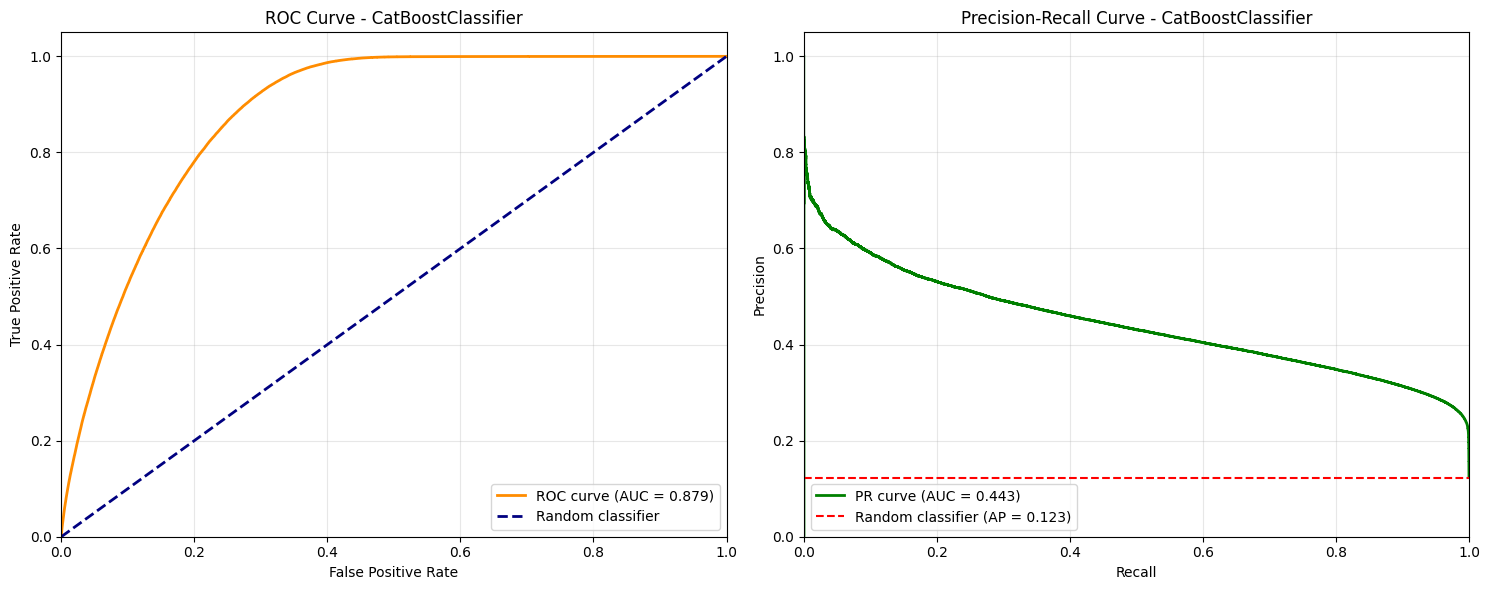

In [36]:
evaluate_model(cb_classifier, X_val, y_val, 'CatBoostClassifier', 'Validation')

Training XGBoost Baseline Model...


/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:30:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



>>> XGBoost Baseline Results <<<

--- Performance on TRAIN set ---
Accuracy score of XGBoost Baseline on train: 0.878
Classification report on train
              precision    recall  f1-score   support

           0       0.88      1.00      0.93   3504424
           1       0.61      0.03      0.05    491615

    accuracy                           0.88   3996039
   macro avg       0.74      0.51      0.49   3996039
weighted avg       0.85      0.88      0.83   3996039

AUC-ROC score of XGBoost Baseline on train: 0.873
AUC-PR score of XGBoost Baseline on train: 0.418


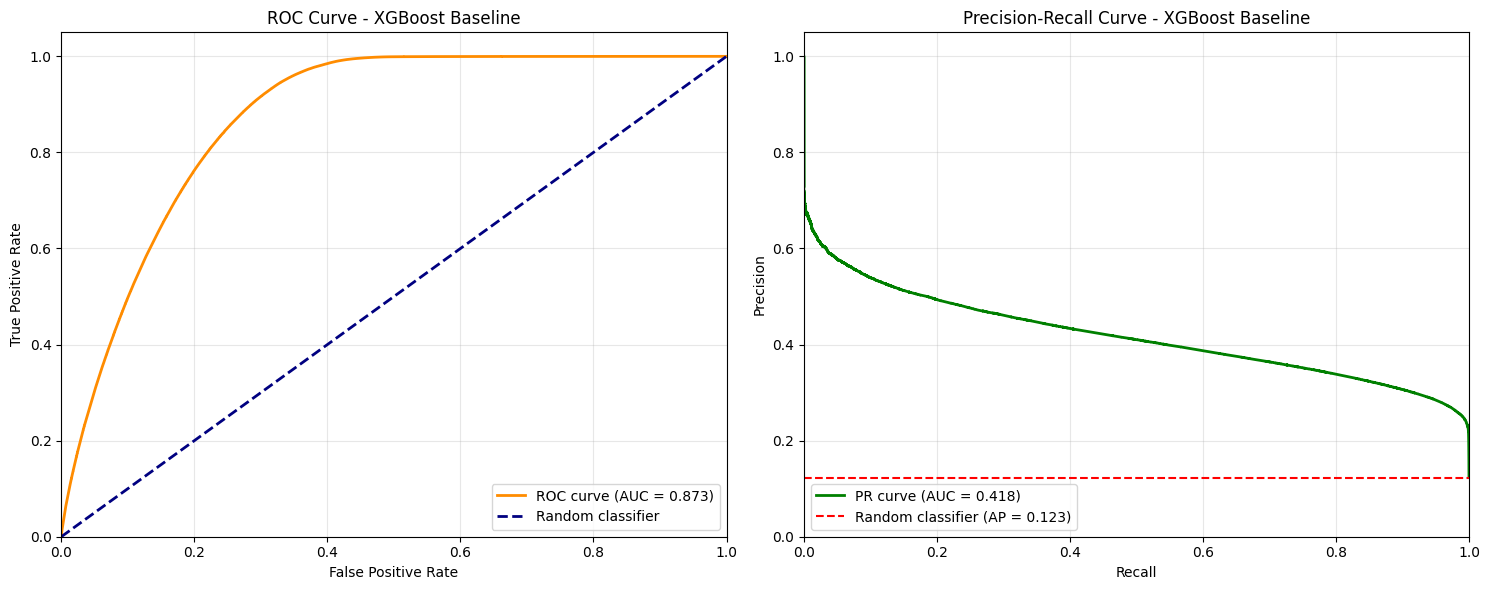


--- Performance on VALIDATION set ---
Accuracy score of XGBoost Baseline on validation: 0.878
Classification report on validation
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    876944
           1       0.61      0.03      0.05    123056

    accuracy                           0.88   1000000
   macro avg       0.74      0.51      0.49   1000000
weighted avg       0.85      0.88      0.83   1000000

AUC-ROC score of XGBoost Baseline on validation: 0.872
AUC-PR score of XGBoost Baseline on validation: 0.415


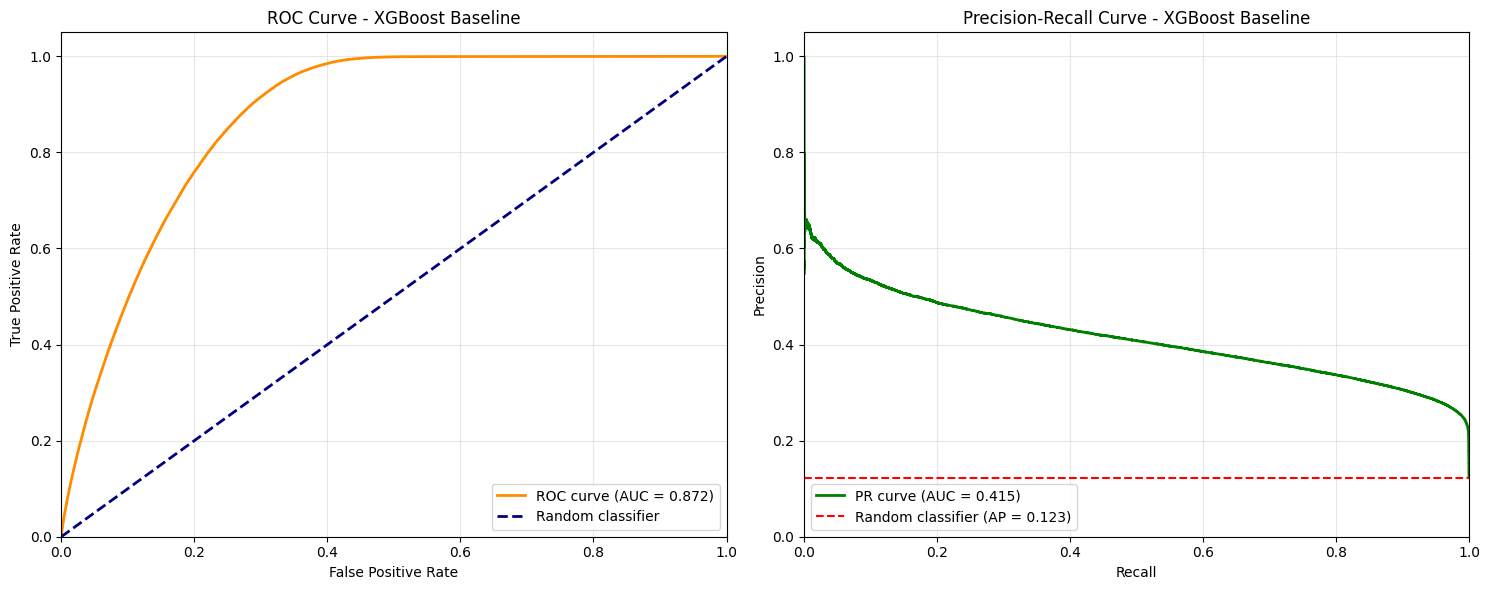


Training LightGBM Baseline Model...
[LightGBM] [Info] Number of positive: 491615, number of negative: 3504424
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.374822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 737
[LightGBM] [Info] Number of data points in the train set: 3996039, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.123026 -> initscore=-1.964086
[LightGBM] [Info] Start training from score -1.964086

>>> LightGBM Baseline Results <<<

--- Performance on TRAIN set ---
Accuracy score of LightGBM Baseline on train: 0.879
Classification report on train
              precision    recall  f1-score   support

           0       0.88      1.00      0.94   3504424
           1       0.63      0.03      0.06    491615

    accuracy                           0.88   3996039
   macro avg       0.75      0.52      0.50   3996039
weighted avg       0.85      0.88      0.

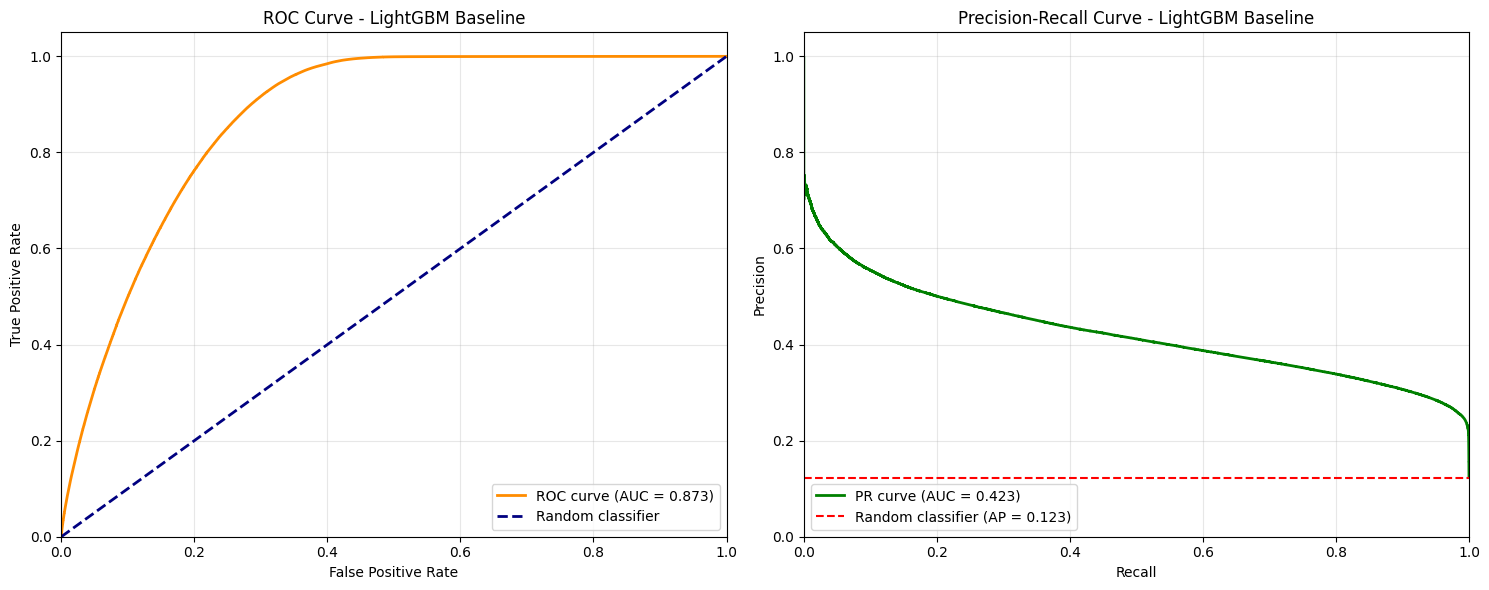


--- Performance on VALIDATION set ---
Accuracy score of LightGBM Baseline on validation: 0.879
Classification report on validation
              precision    recall  f1-score   support

           0       0.88      1.00      0.94    876944
           1       0.63      0.03      0.06    123056

    accuracy                           0.88   1000000
   macro avg       0.75      0.52      0.50   1000000
weighted avg       0.85      0.88      0.83   1000000

AUC-ROC score of LightGBM Baseline on validation: 0.873
AUC-PR score of LightGBM Baseline on validation: 0.421


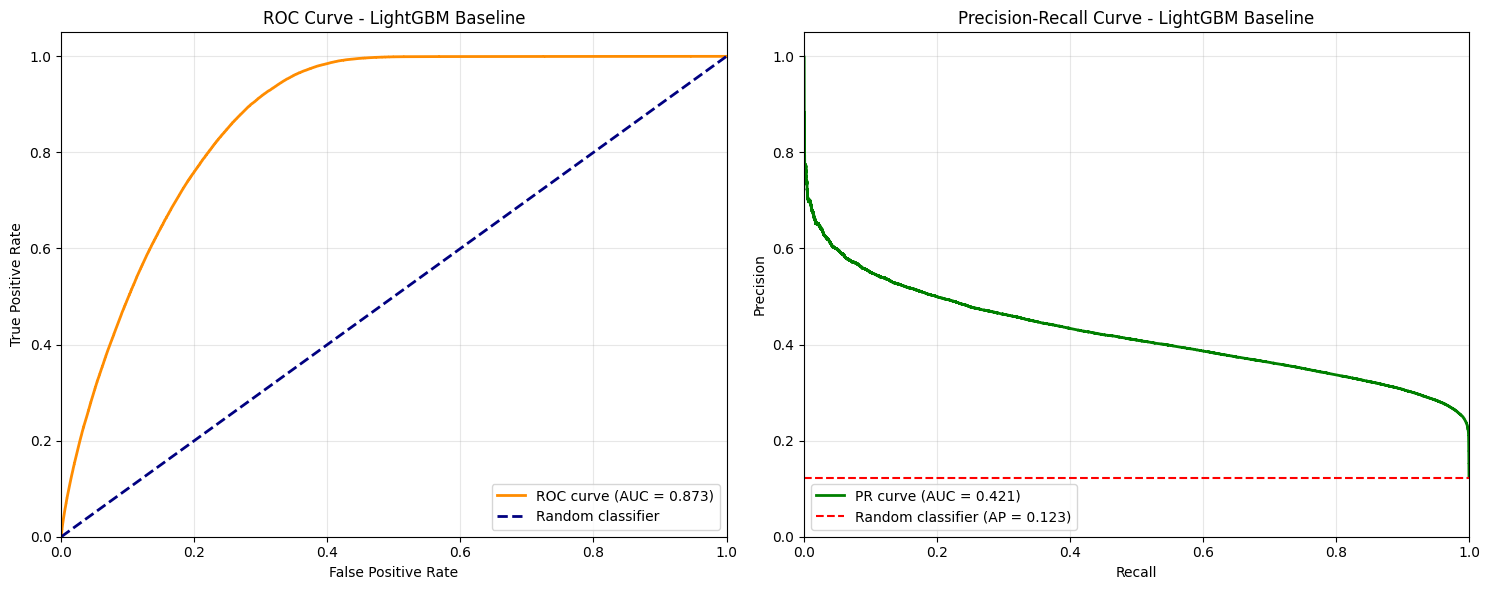

In [22]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# Функции calculate_auc_scores и plot_roc_pr_curves (предполагается, что они определены)
# Если их нет, см. реализацию в конце ответа.
# from your_module import calculate_auc_scores, plot_roc_pr_curves

def evaluate_model(model, X_val, y_val, model_name, data_name):
    """Evaluates model on X_val data with y_val labels as ground truth."""
    preds = model.predict(X_val)

    print(f'Accuracy score of {model_name} on {data_name}: {accuracy_score(y_val, preds):.3f}')

    print(f'Classification report on {data_name}')
    print(classification_report(y_val, preds))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_val)[:, 1]
    else:
        y_scores = model.decision_function(X_val)

    roc_auc, pr_auc = calculate_auc_scores(y_scores, y_val)

    print(f'AUC-ROC score of {model_name} on {data_name}: {roc_auc:.3f}')
    print(f'AUC-PR score of {model_name} on {data_name}: {pr_auc:.3f}')

    plot_roc_pr_curves(y_scores, y_val, model_name)

# 1. Обучение XGBoost
print("=" * 60)
print("Training XGBoost Baseline Model...")
print("=" * 60)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True,  # Ключевой параметр для категорий
    use_label_encoder=False   # Отключаем внутренний LabelEncoder
)

xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("\n>>> XGBoost Baseline Results <<<")
print("\n--- Performance on TRAIN set ---")
evaluate_model(xgb_model, X_train, y_train, "XGBoost Baseline", "train")
print("\n--- Performance on VALIDATION set ---")
evaluate_model(xgb_model, X_val, y_val, "XGBoost Baseline", "validation")

# 2. Обучение LightGBM
print("\n" + "=" * 60)
print("Training LightGBM Baseline Model...")
print("=" * 60)

# LightGBM требует явного указания категориальных признаков.
# При fit() они передаются через categorical_feature.
# Важно: типы данных должны быть int.
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

lgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='logloss',
    categorical_feature=categorical_features  # Указываем категориальные колонки
)

print("\n>>> LightGBM Baseline Results <<<")
print("\n--- Performance on TRAIN set ---")
evaluate_model(lgb_model, X_train, y_train, "LightGBM Baseline", "train")
print("\n--- Performance on VALIDATION set ---")
evaluate_model(lgb_model, X_val, y_val, "LightGBM Baseline", "validation")

Обучим так же RandomForestClassifier и SVC:

Training Random Forest Baseline Model...

>>> Random Forest Baseline Results <<<

--- Performance on TRAIN set ---
Accuracy score of Random Forest on train: 0.877
Classification report on train
              precision    recall  f1-score   support

           0       0.88      1.00      0.93   3504424
           1       0.00      0.00      0.00    491615

    accuracy                           0.88   3996039
   macro avg       0.44      0.50      0.47   3996039
weighted avg       0.77      0.88      0.82   3996039

AUC-ROC score of Random Forest on train: 0.855
AUC-PR score of Random Forest on train: 0.365


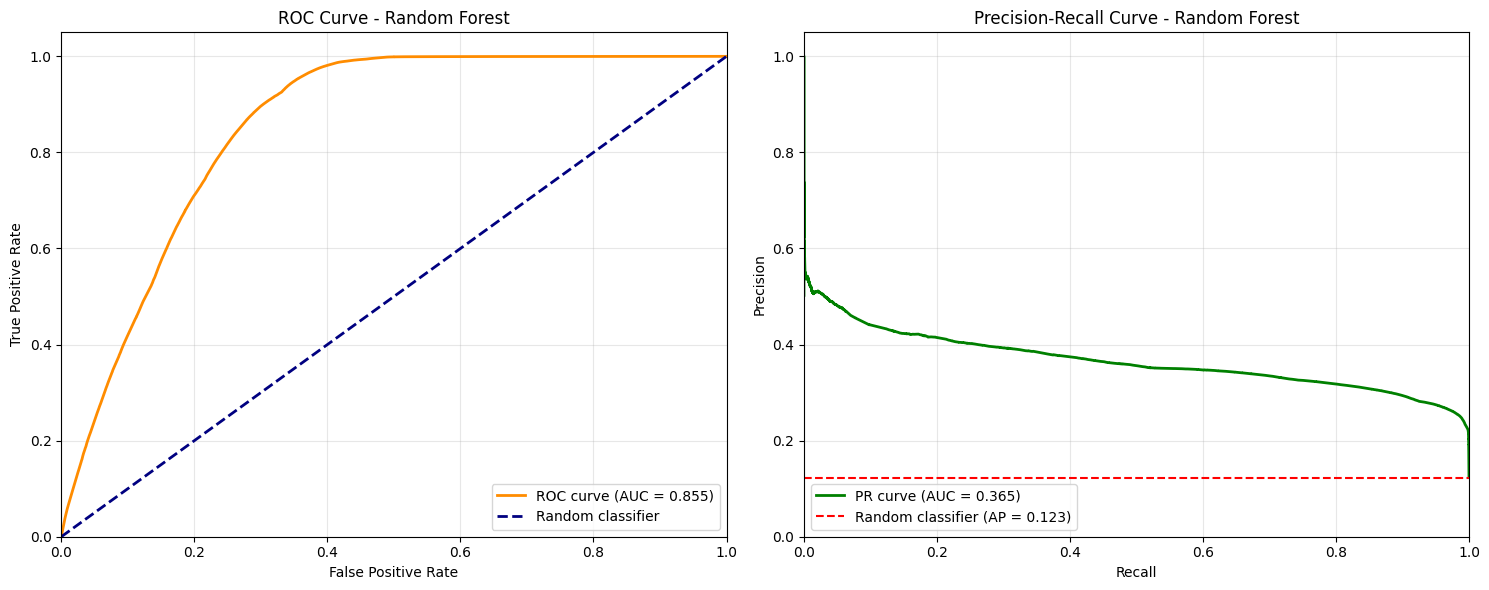


--- Performance on VALIDATION set ---
Accuracy score of Random Forest on validation: 0.877
Classification report on validation
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    876944
           1       0.00      0.00      0.00    123056

    accuracy                           0.88   1000000
   macro avg       0.44      0.50      0.47   1000000
weighted avg       0.77      0.88      0.82   1000000

AUC-ROC score of Random Forest on validation: 0.855
AUC-PR score of Random Forest on validation: 0.366


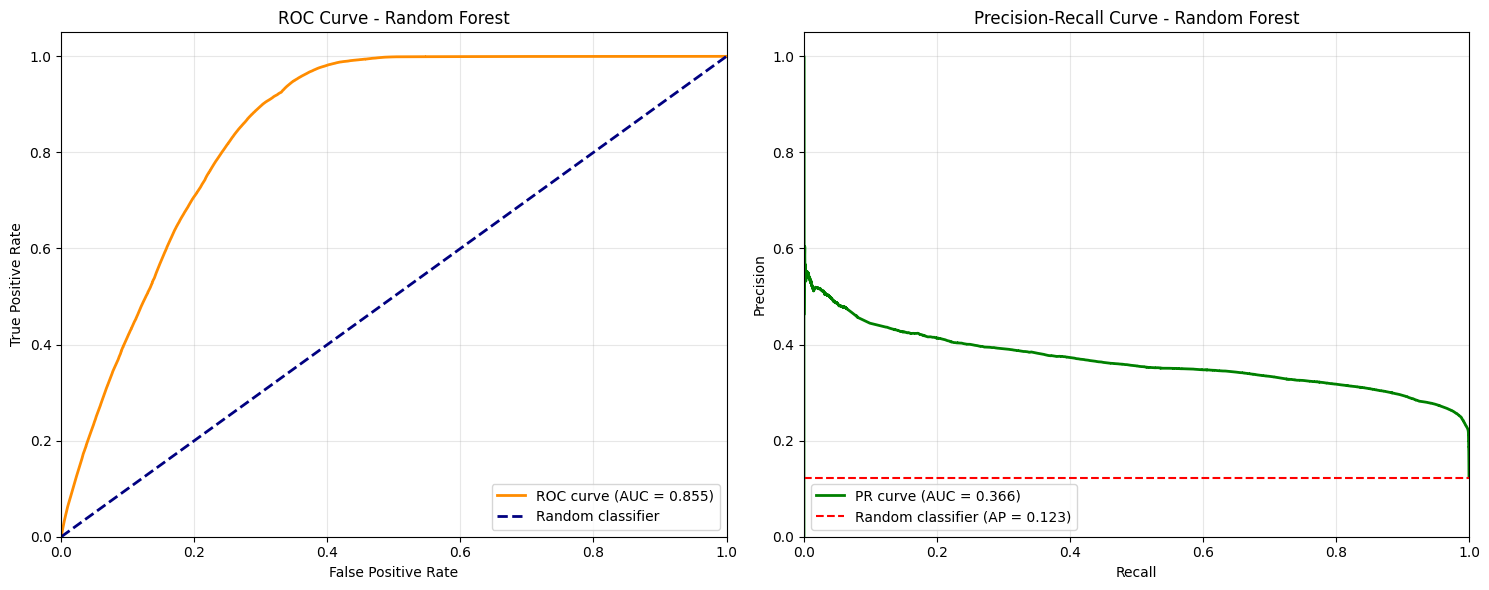

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# 1. Обучение RandomForestClassifier
print("=" * 60)
print("Training Random Forest Baseline Model...")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("\n>>> Random Forest Baseline Results <<<")
print("\n--- Performance on TRAIN set ---")
evaluate_model(rf_model, X_train, y_train, "Random Forest", "train")
print("\n--- Performance on VALIDATION set ---")
evaluate_model(rf_model, X_val, y_val, "Random Forest", "validation")


Предупреждение: обучается долго.

In [ ]:
# 2. Обучение Support Vector Classifier
print("\n" + "=" * 60)
print("Training SVC Baseline Model...")
print("=" * 60)

svc_model = SVC(
    C=1.0,
    kernel='rbf',
    random_state=42,
    probability=True  # Важно: включаем для получения predict_proba
)

svc_model.fit(X_train, y_train)

print("\n>>> SVC Baseline Results <<<")
print("\n--- Performance on TRAIN set ---")
evaluate_model(svc_model, X_train, y_train, "SVC", "train")
print("\n--- Performance on VALIDATION set ---")
evaluate_model(svc_model, X_val, y_val, "SVC", "validation")

### Оценка и время инференса

In [24]:
from sklearn.metrics import f1_score

In [29]:
import time

In [25]:
def measure_inference_time(model, X, y_true, model_name, score_fn, n_runs=5):
    times = []
    
    # Прогрев (первый запуск часто медленнее из-за инициализации)
    _ = model.predict(X[:10])

    
    # Основные замеры
    for _ in range(n_runs):
        start_time = time.perf_counter()  # Высокая точность
        pred = model.predict(X)
        end_time = time.perf_counter()
        times.append(end_time - start_time)
        score = (score_fn(y_true, pred))
    
    # Расчет статистик
    avg_time = sum(times) / len(times) * 1000  # в миллисекундах
    std_time = (max(times) - min(times)) / 2 * 1000  # полуразмах как оценка разброса
    
    # Создаем DataFrame для удобства
    results_df = pd.DataFrame({
        'Модель': [model_name],
        'f1': [f"{score:.2f}"],
        'Среднее время (мс)': [f"{avg_time:.2f}"],
        'Разброс (±мс)': [f"{std_time:.2f}"],
        'Размер выборки': [len(X)],
        'Прогонов': [n_runs]
    })
    
    return results_df, times, score

In [38]:
models = [
    (cb_classifier, "CatBoost"),
    (xgb_model, "XGBoost"),
    (lgb_model, "LightGBM"),
    (rf_model, "Random Forest")
]

In [39]:
scores = []

all_results = []
print("=== СРАВНЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА МОДЕЛЕЙ ===\n")

for model, name in models:
    print(f"Измерение для {name}...")
    result_df, _, score = measure_inference_time(model, X_val, y_val, name, f1_score, n_runs=50)
    scores.append(score)
    all_results.append(result_df)
    print(f"   Готово: {result_df['Среднее время (мс)'].values[0]} мс ± {result_df['Разброс (±мс)'].values[0]} мс")

# Объединяем все результаты в одну таблицу
summary_df = pd.concat(all_results, ignore_index=True)
print("\n" + "=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА ПРОИЗВОДИТЕЛЬНОСТИ:")
print("=" * 70)
print(summary_df.to_string(index=False))
    

=== СРАВНЕНИЕ ВРЕМЕНИ ИНФЕРЕНСА МОДЕЛЕЙ ===

Измерение для CatBoost...
   Готово: 1859.36 мс ± 225.37 мс
Измерение для XGBoost...
   Готово: 740.49 мс ± 52.36 мс
Измерение для LightGBM...
   Готово: 2055.10 мс ± 111.89 мс
Измерение для Random Forest...
   Готово: 976.44 мс ± 30.80 мс

ИТОГОВАЯ ТАБЛИЦА ПРОИЗВОДИТЕЛЬНОСТИ:
       Модель   f1 Среднее время (мс) Разброс (±мс)  Размер выборки  Прогонов
     CatBoost 0.21            1859.36        225.37         1000000        50
      XGBoost 0.05             740.49         52.36         1000000        50
     LightGBM 0.06            2055.10        111.89         1000000        50
Random Forest 0.00             976.44         30.80         1000000        50


Проверим, не получилось ли значимого дисбаланса на трейне и валидации:

In [41]:
y_val.mean()

np.float64(0.123056)

In [42]:
y_train.mean()

np.float64(0.12302557607670996)

Итог - надо тюнить модели, время инференса не стало сюрпризом.